# Metrics-evaluation

Using the csvs generated in the previous notebook we will calculate the relevant metrics that are shown in the paper

In [1]:
# External Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import display
import time
import matplotlib.dates as mdates
from IPython.display import display, HTML
import glob
import pickle

# Local Libraries
import reldi_modules
import utils
import pre_processing
import storm_dates
import metrics
import constants

# configs
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.set_option('display.max_columns', None)


/mnt/data/ldi-forecast-1and2-hours/ldi-torch/lib/python3.12/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Processing station: ABG


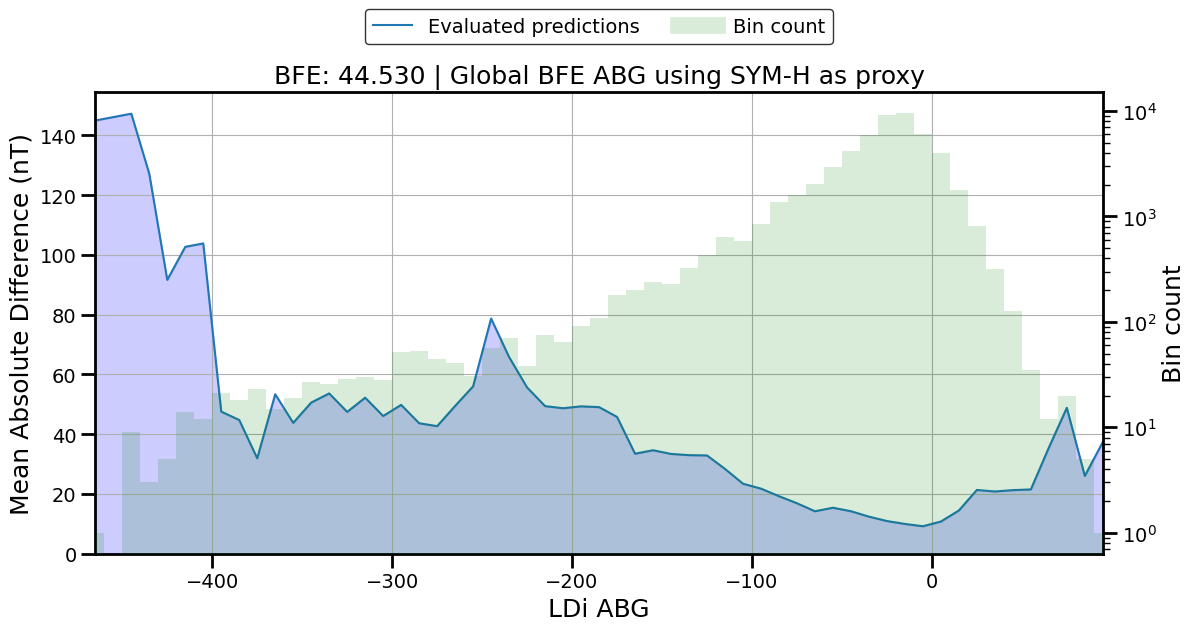

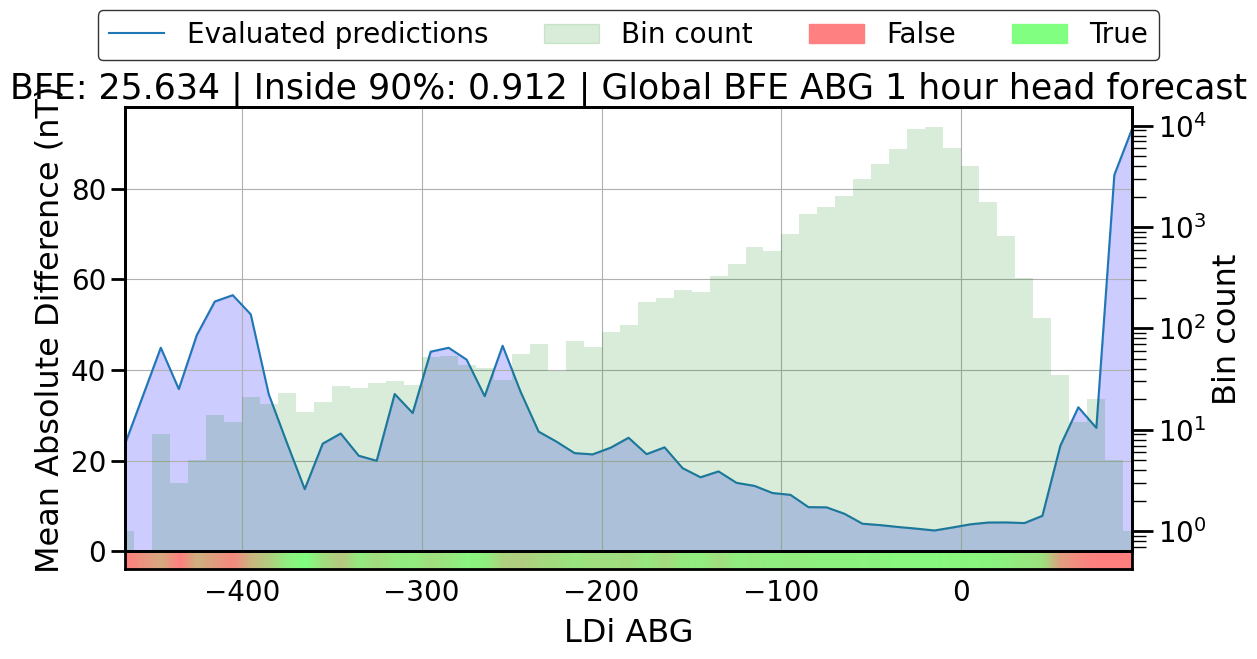

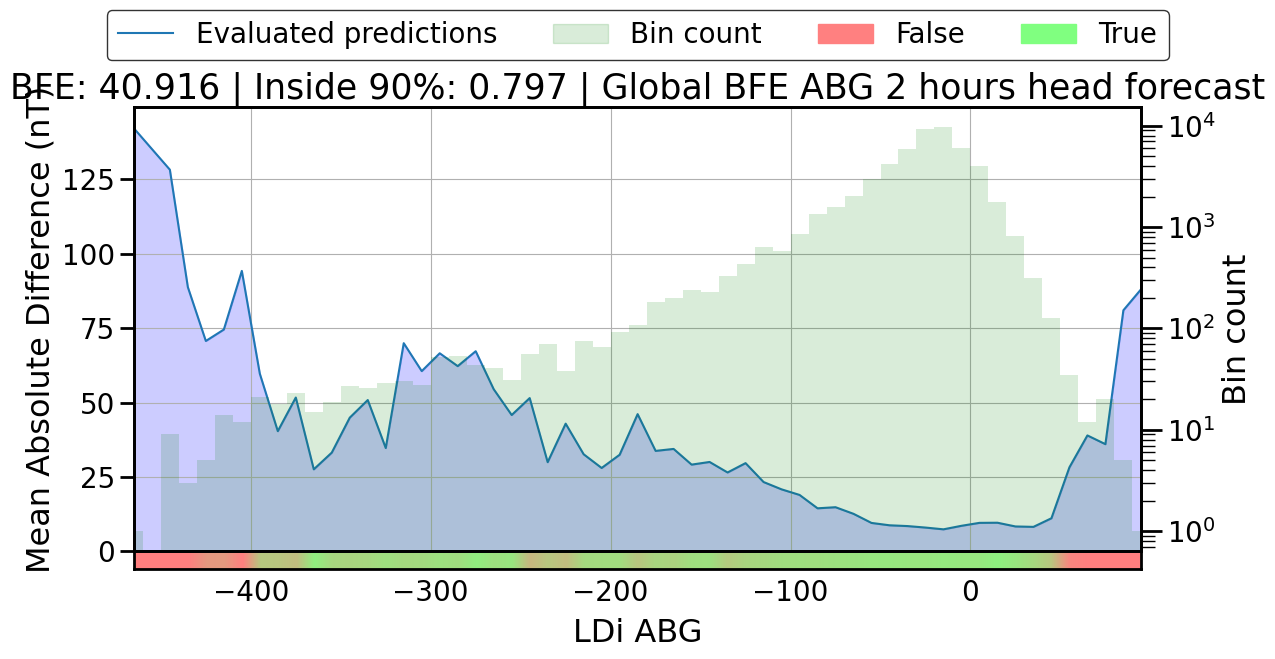

Processing station: MMB


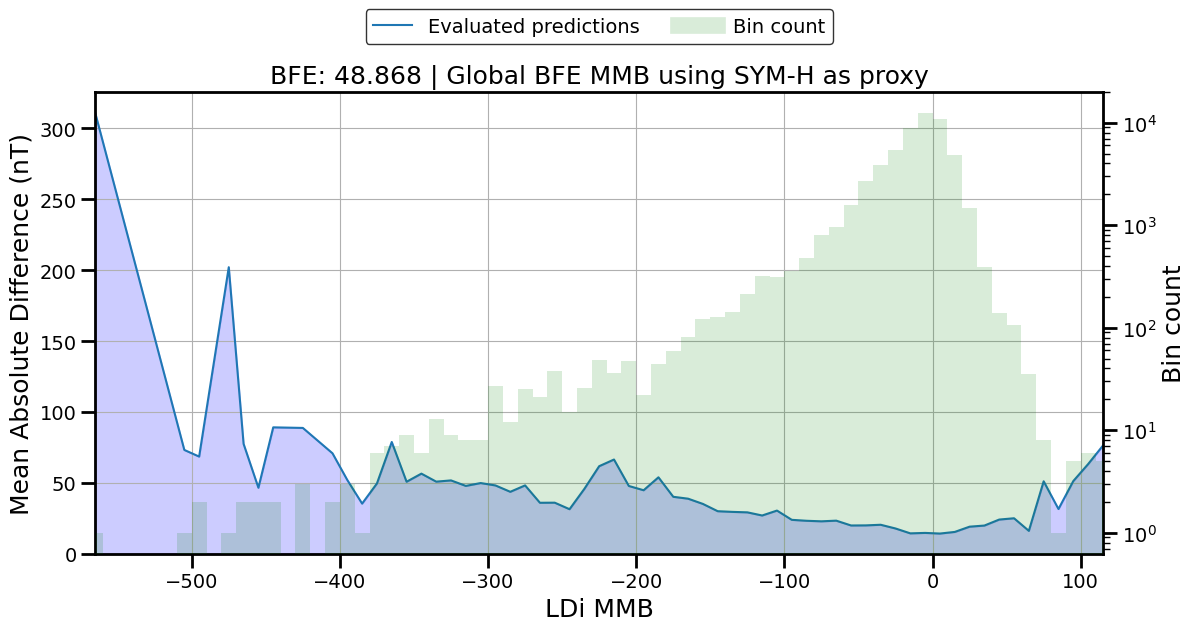

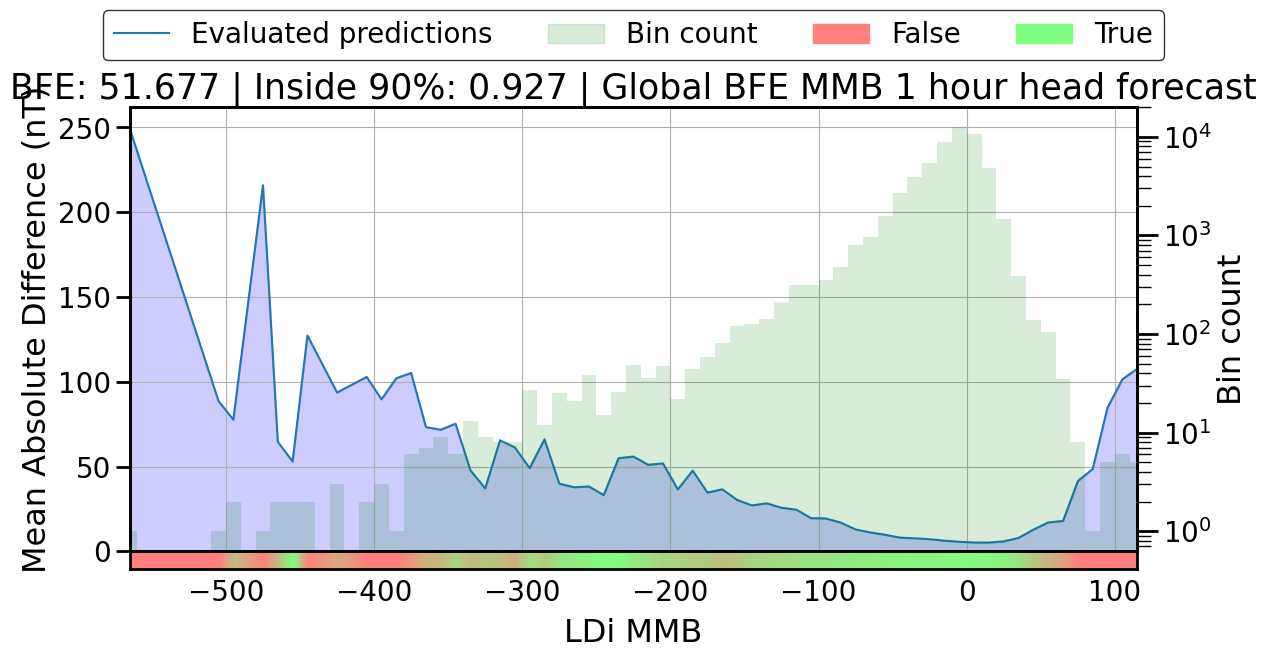

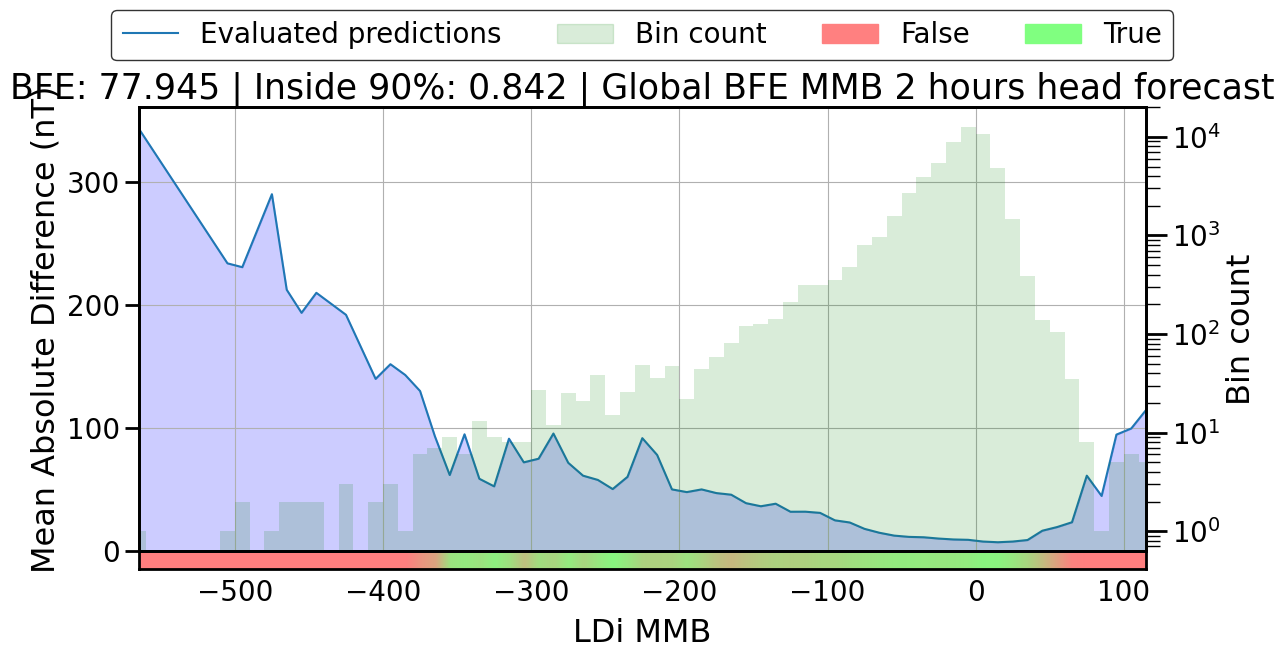

Processing station: CLF


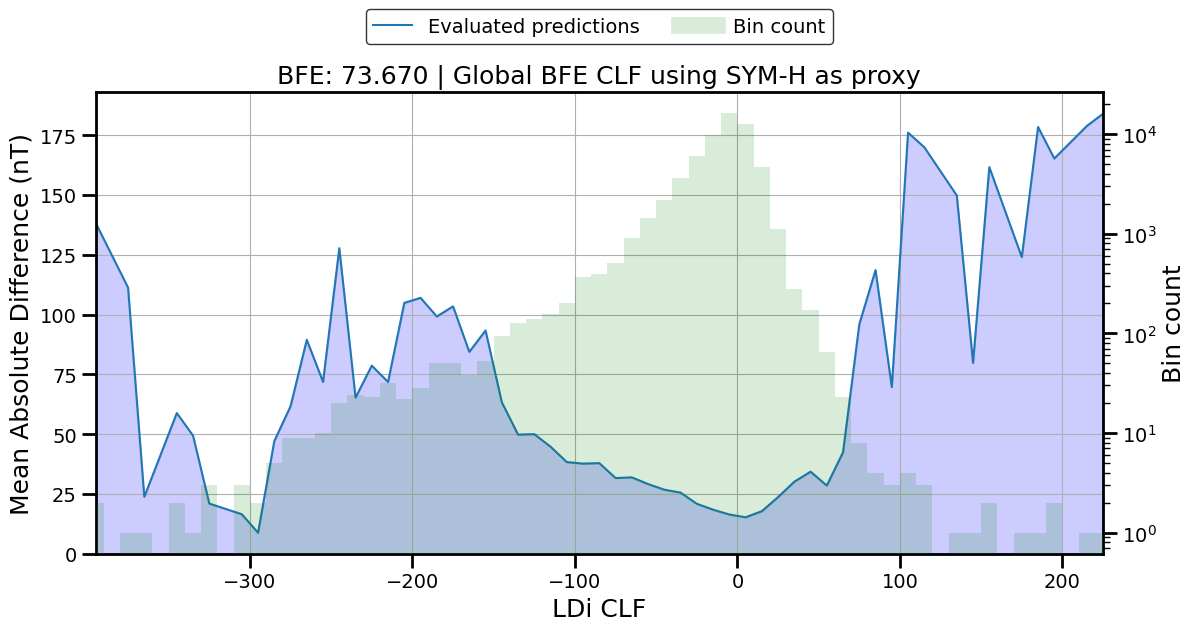

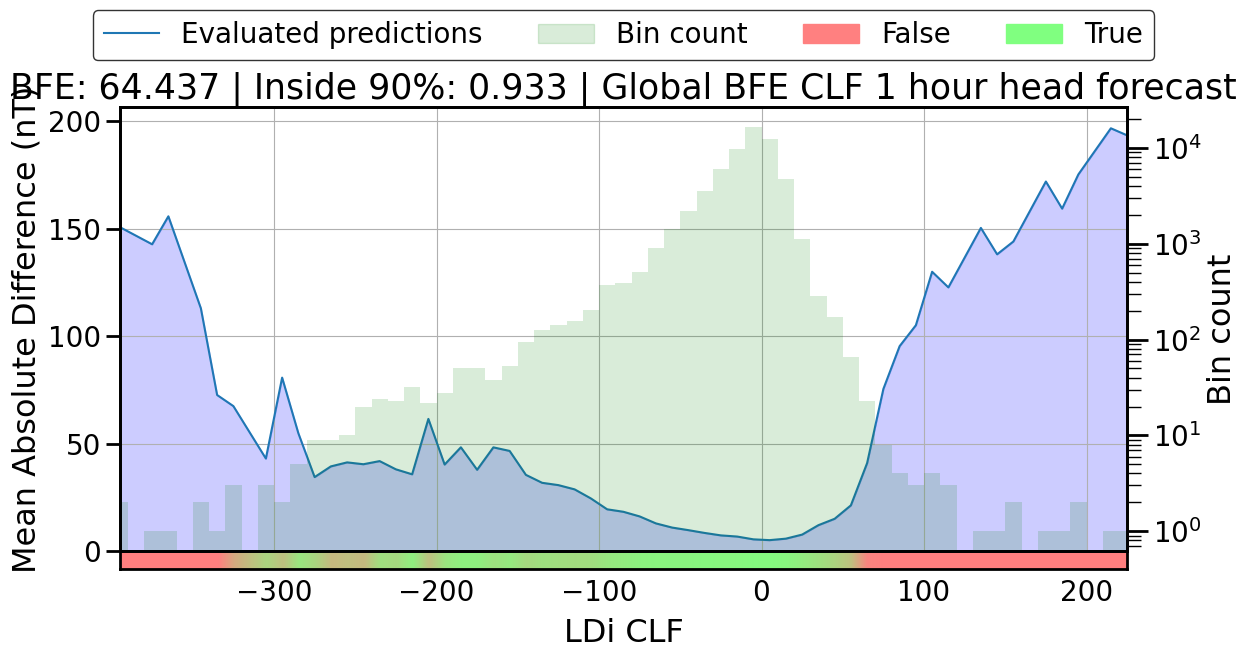

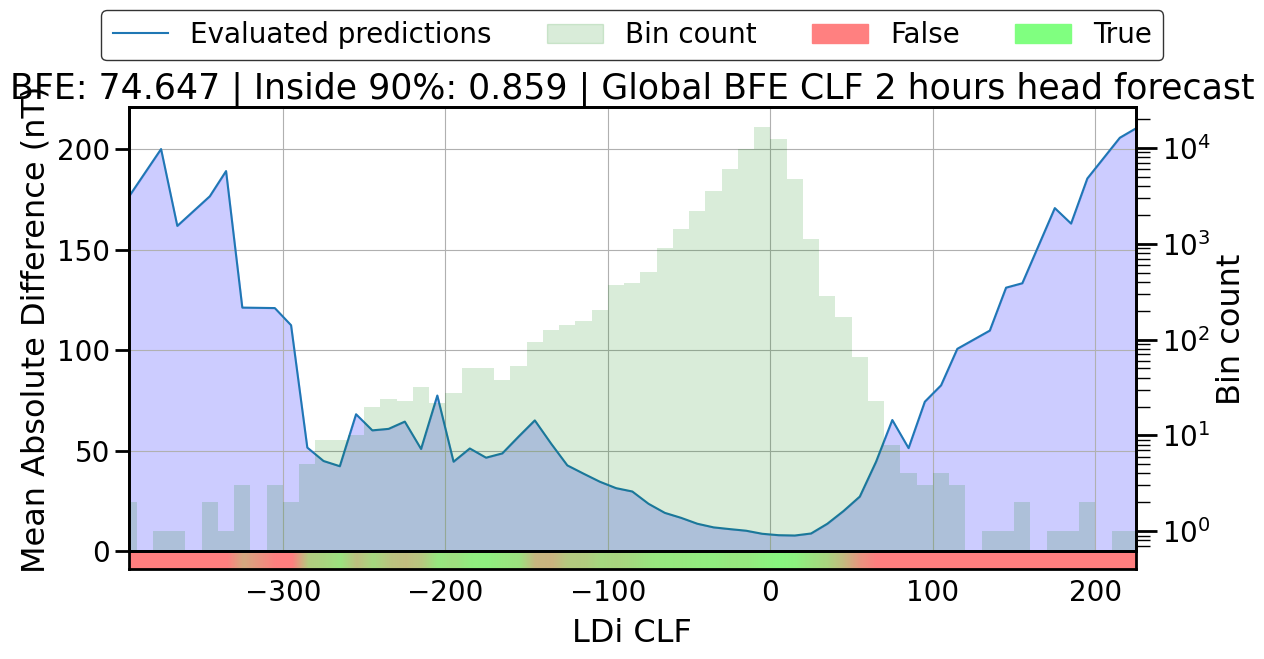

Processing station: TUC


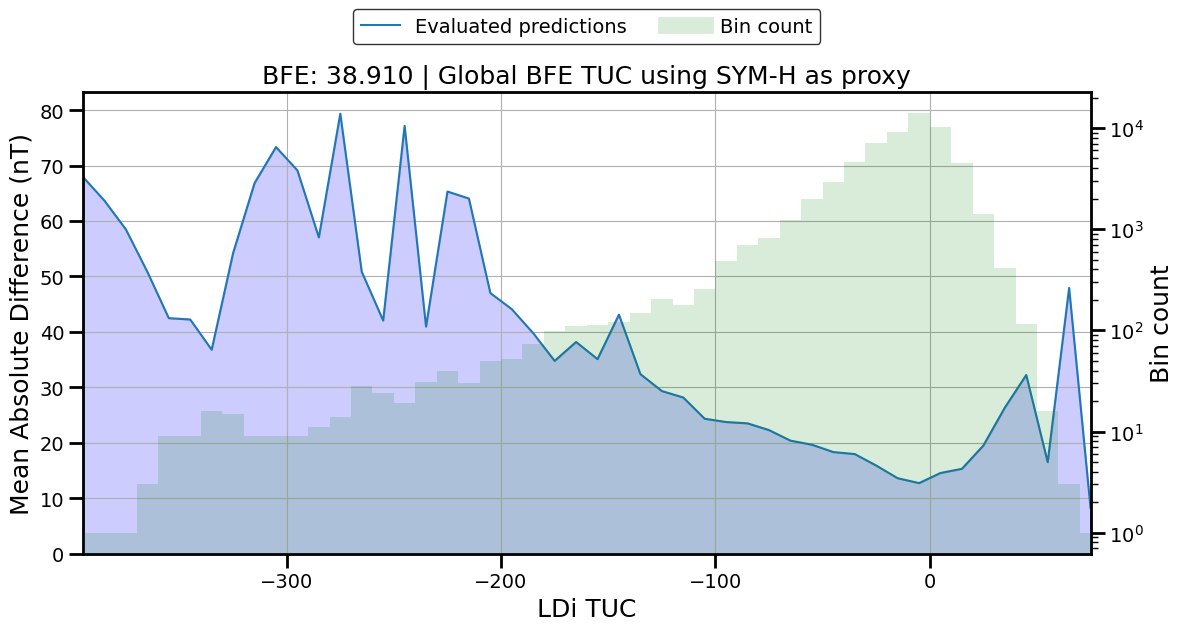

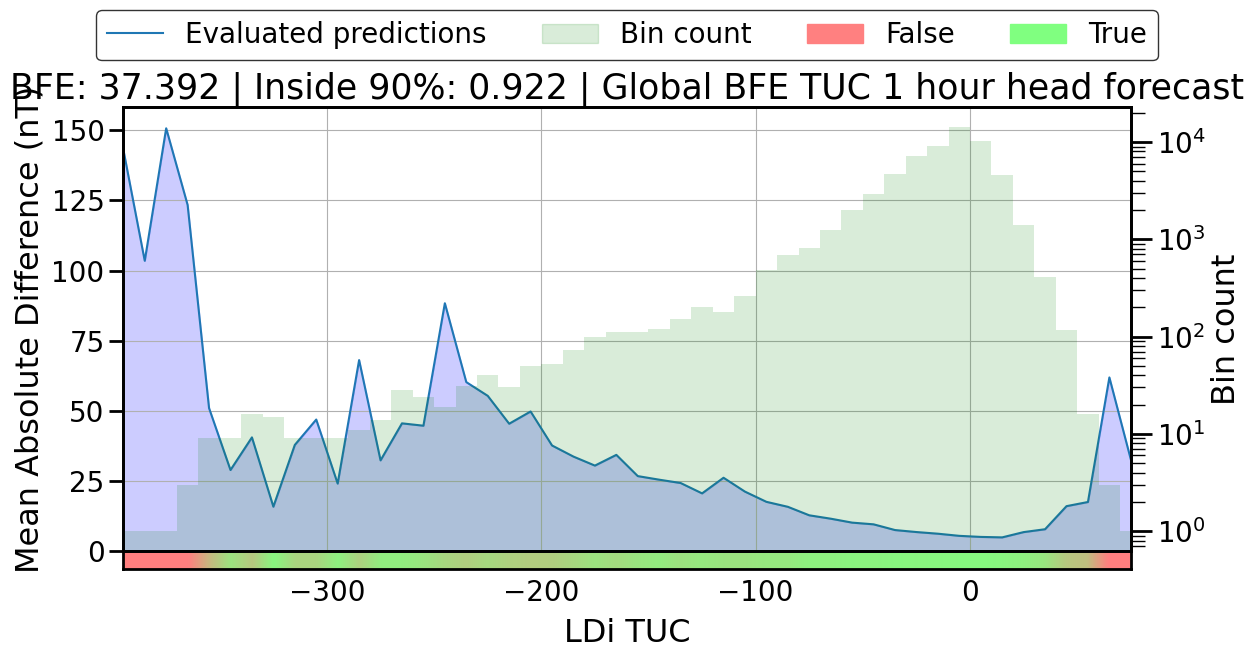

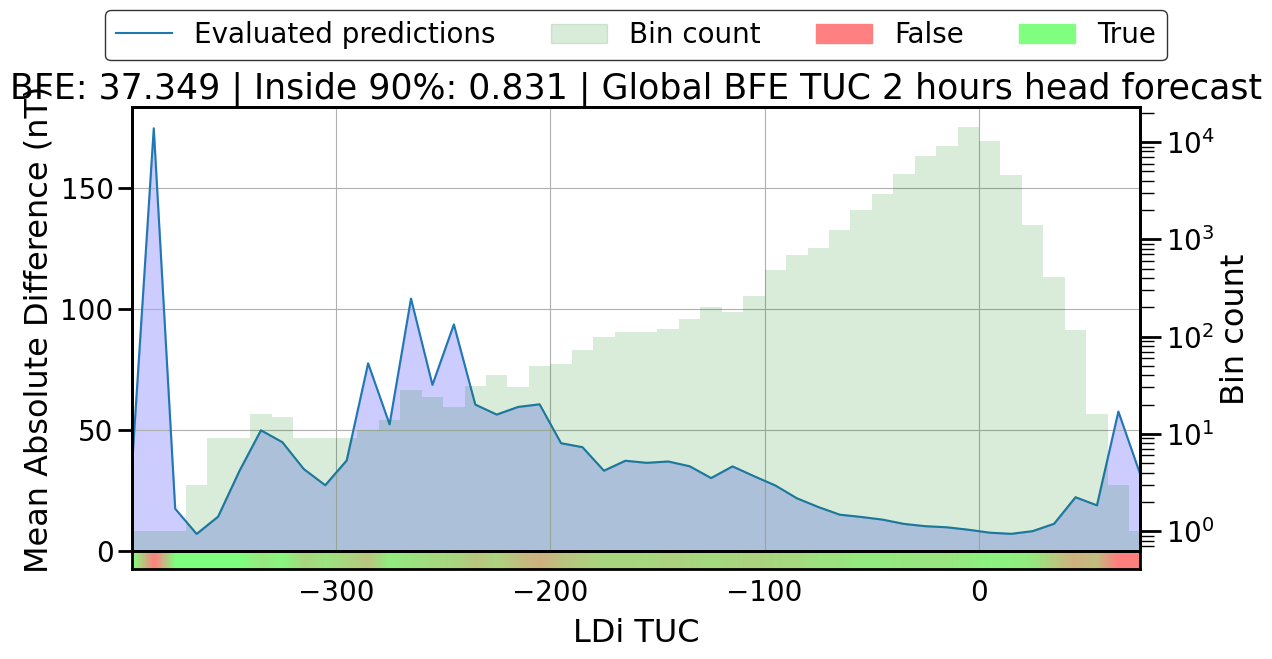

Processing station: HON


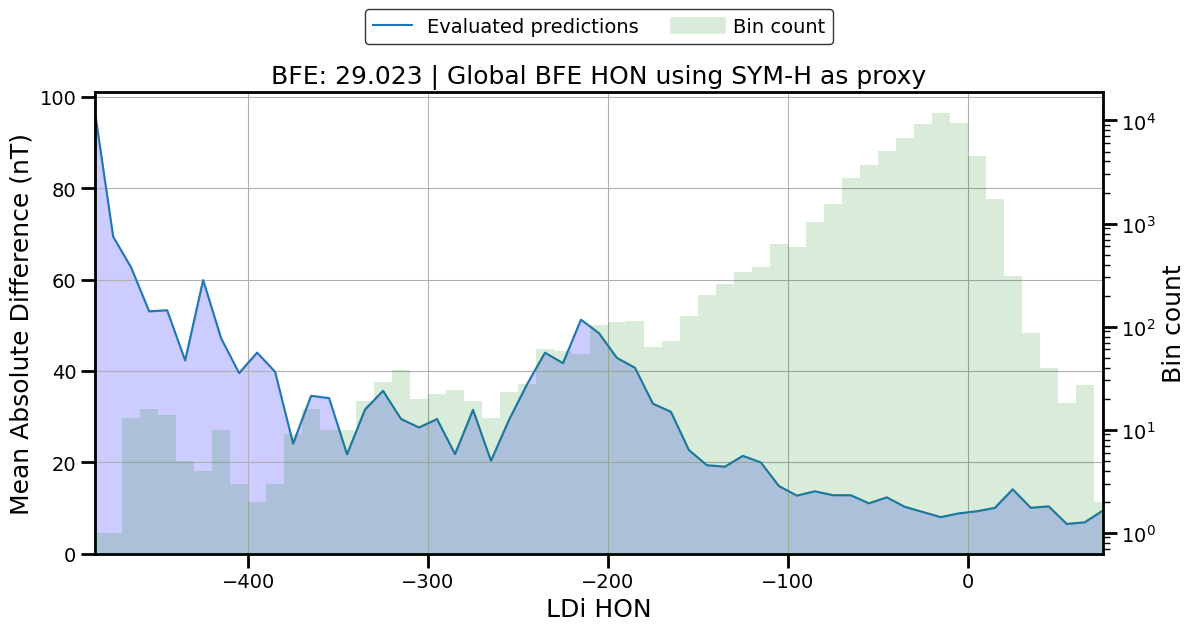

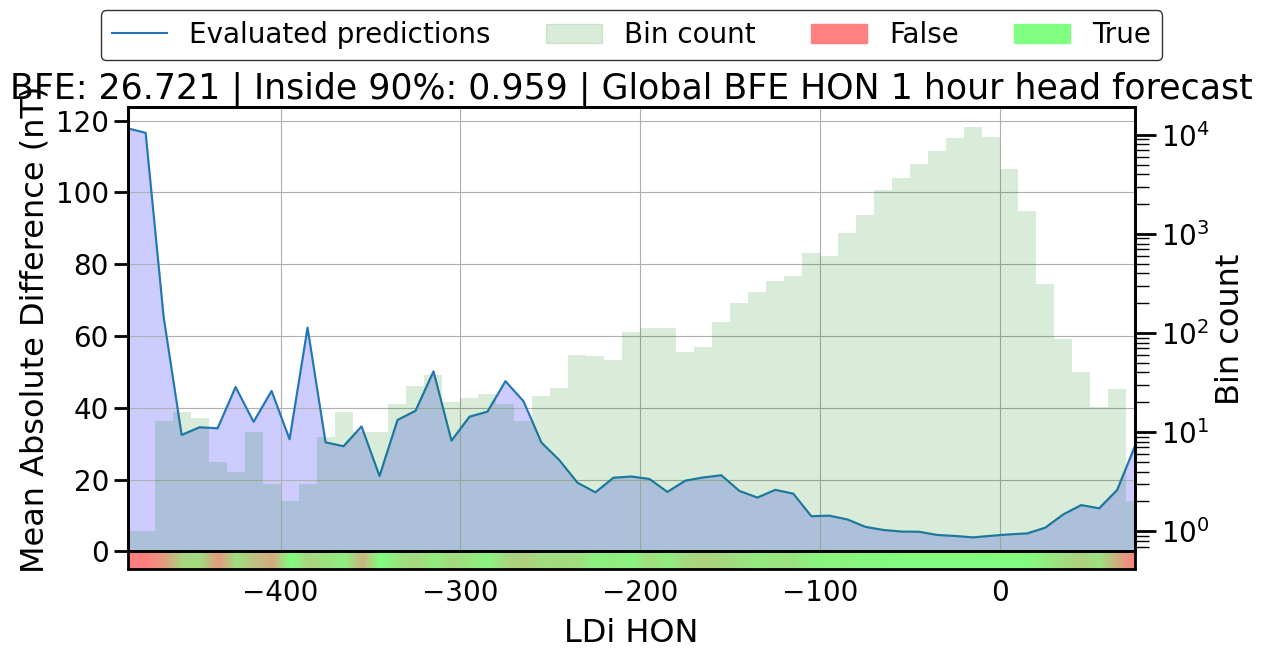

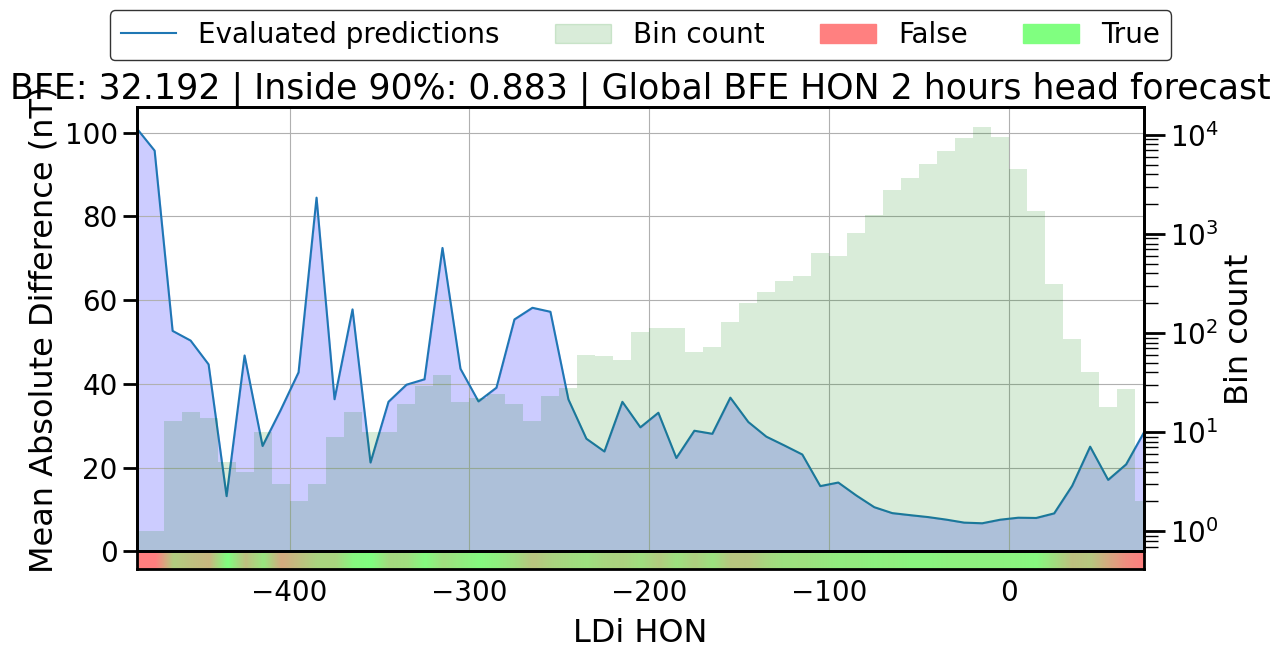

Processing station: SFS


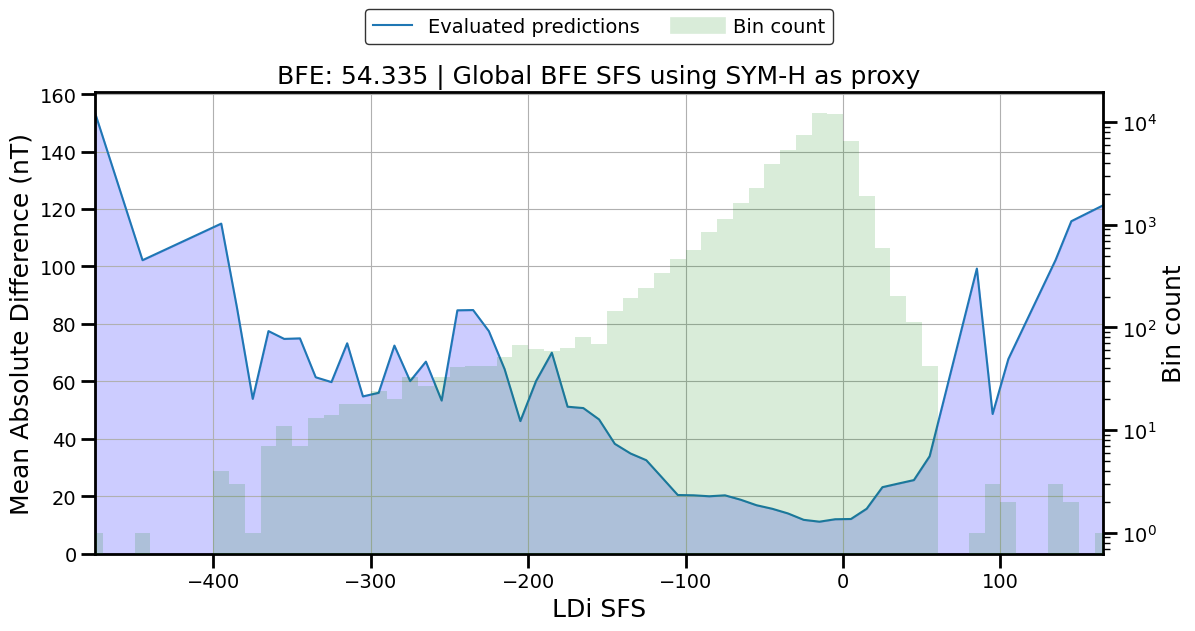

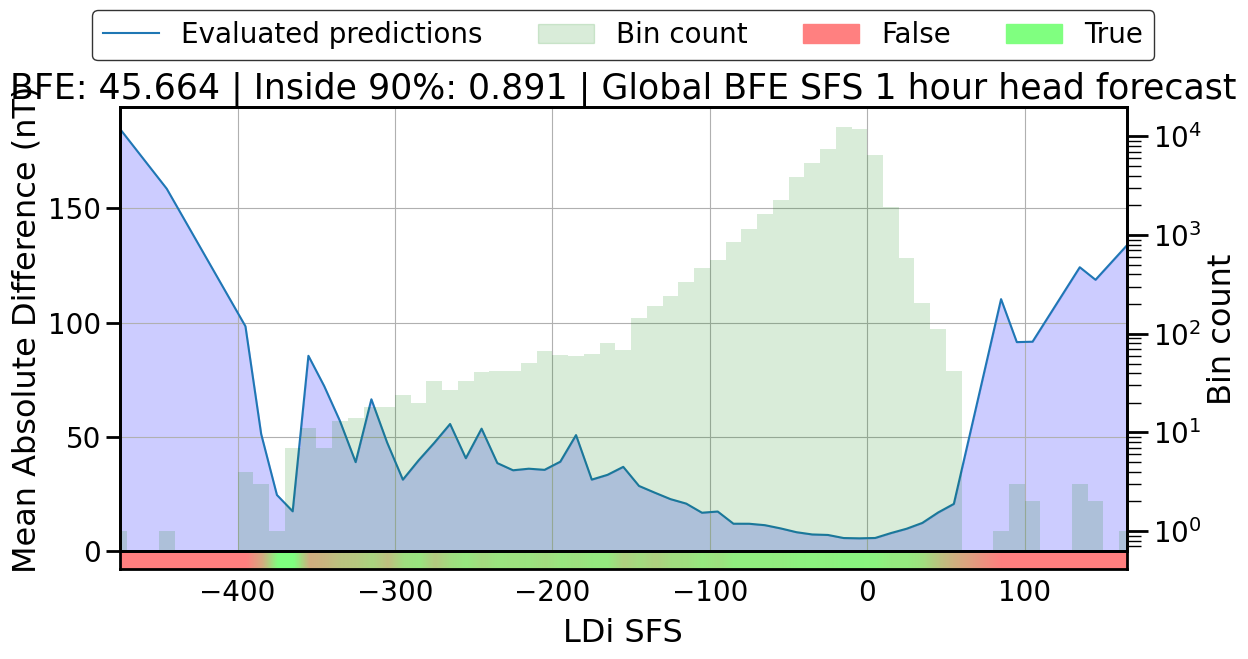

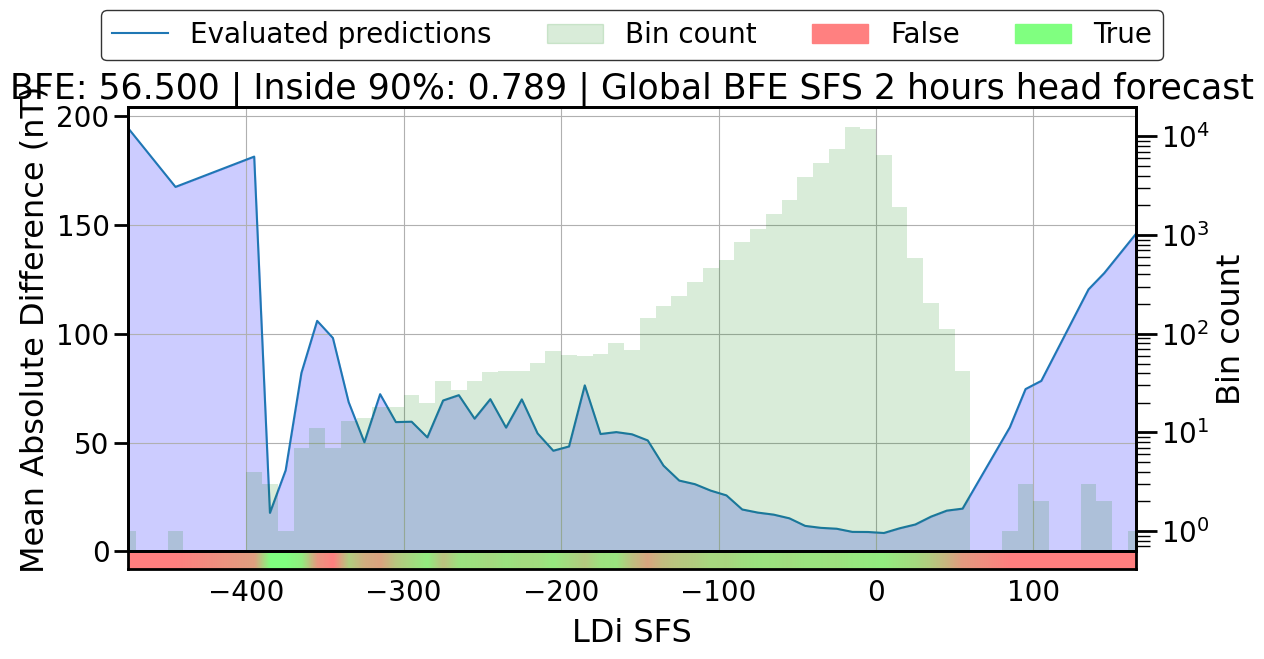

In [2]:
dfs_stations_sym = {}
dfs_stations_1h = {}
dfs_stations_2h = {}
dfs_stations_persistence_1h = {}
dfs_stations_persistence_2h = {}

for station in constants.STATIONS:
    print(f"Processing station: {station}")    

    csv_files = glob.glob(f'./predictions/{station}/*.csv')
    # Filter each dataframe to only include rows within the storm dates
    dfs_station = [pd.read_csv(f, index_col=0, parse_dates=True) for f in csv_files]
    for df_1h in dfs_station:
        df_1h.index.name = 'datetime'
        df_1h.index = pd.to_datetime(df_1h.index)

    # Concatenate all dataframes for the station
    df_all = pd.concat(dfs_station).sort_index()

    # 1. DataFrame with observed LDi, SYM-H, and their difference
    df_omni = pd.DataFrame({
        f'LDi_{station}': df_all[f'LDi_{station}'],
        'SYM_H': df_all['SYM_H'],
    })
    df_omni['diff_sym'] = df_omni[f'LDi_{station}'] - df_omni['SYM_H']

    # 2. DataFrame with observed LDi at 1h, predicted LDi at 1h, and their difference (shift index by 1h)
    obs_1h = f'Observed_LDi_{station}-1h'
    pred_1h = f'Predicted_LDi_{station}-1h'
    quantile_lower_1h = f'Quantile_05_LDi_{station}-1h'
    quantile_upper_1h = f'Quantile_95_LDi_{station}-1h'
    inside_90_1h = f'inside_90%_LDi_{station}-1h'
    
    
    df_1h = pd.DataFrame({
        obs_1h: df_all[obs_1h],
        pred_1h: df_all[pred_1h],
        quantile_lower_1h: df_all[quantile_lower_1h],
        quantile_upper_1h: df_all[quantile_upper_1h],
        inside_90_1h: df_all[inside_90_1h],
    })
    df_1h['diff_1h'] = df_1h[obs_1h] - df_1h[pred_1h]
    df_1h.index = df_1h.index + pd.Timedelta(hours=1)

    # 3. DataFrame with observed LDi at 2h, predicted LDi at 2h, and their difference (shift index by 2h)
    obs_2h = f'Observed_LDi_{station}-2h'
    pred_2h = f'Predicted_LDi_{station}-2h'
    quantile_lower_2h = f'Quantile_05_LDi_{station}-2h'
    quantile_upper_2h = f'Quantile_95_LDi_{station}-2h'
    inside_90_2h = f'inside_90%_LDi_{station}-2h'
    
    df_2h = pd.DataFrame({
        obs_2h: df_all[obs_2h],
        pred_2h: df_all[pred_2h],
        quantile_lower_2h: df_all[quantile_lower_2h],
        quantile_upper_2h: df_all[quantile_upper_2h],
        inside_90_2h: df_all[inside_90_2h],
    })
    df_2h['diff_2h'] = df_2h[obs_2h] - df_2h[pred_2h]
    df_2h.index = df_2h.index + pd.Timedelta(hours=2)
    
    df_persistence_1h = pd.DataFrame({
        f'Observed_LDi_{station}-1h': df_all[obs_1h],
        f'Persistence_LDi_{station}-1h': df_all[f'LDi_{station}'],
    })
    df_persistence_1h['diff_persistence_1h'] = df_persistence_1h[f'Observed_LDi_{station}-1h'] - df_persistence_1h[f'Persistence_LDi_{station}-1h']
    df_persistence_1h.index = df_persistence_1h.index + pd.Timedelta(hours=1)

    # 2h persistence
    df_persistence_2h = pd.DataFrame({
        f'Observed_LDi_{station}-2h': df_all[obs_2h],
        f'Persistence_LDi_{station}-2h': df_all[f'LDi_{station}'],
    })
    df_persistence_2h['diff_persistence_2h'] = df_persistence_2h[f'Observed_LDi_{station}-2h'] - df_persistence_2h[f'Persistence_LDi_{station}-2h']
    df_persistence_2h.index = df_persistence_2h.index + pd.Timedelta(hours=2)

    # Filter for storm periods
    dfs_filtered_persistence_1h = []
    dfs_filtered_persistence_2h = []

    # Now filter each dataframe for storm periods
    dfs_filtered_omni = []
    dfs_filtered_1h = []
    dfs_filtered_2h = []
    for start_str, end_str, idx in storm_dates.TEST_STORMS:
        start_date = pd.to_datetime(start_str)
        end_date = pd.to_datetime(end_str)
        dfs_filtered_omni.append(df_omni[(df_omni.index >= start_date) & (df_omni.index <= end_date)])
        dfs_filtered_1h.append(df_1h[(df_1h.index >= start_date) & (df_1h.index <= end_date)])
        dfs_filtered_2h.append(df_2h[(df_2h.index >= start_date) & (df_2h.index <= end_date)])
        dfs_filtered_persistence_1h.append(df_persistence_1h[(df_persistence_1h.index >= start_date) & (df_persistence_1h.index <= end_date)])
        dfs_filtered_persistence_2h.append(df_persistence_2h[(df_persistence_2h.index >= start_date) & (df_persistence_2h.index <= end_date)])


    dfs_station_sym = pd.concat(dfs_filtered_omni)
    dfs_station_1h = pd.concat(dfs_filtered_1h)
    dfs_station_2h = pd.concat(dfs_filtered_2h)
    dfs_station_persistence_1h = pd.concat(dfs_filtered_persistence_1h)
    dfs_station_persistence_2h = pd.concat(dfs_filtered_persistence_2h)
    dfs_stations_sym[station] = pd.concat(dfs_filtered_omni)
    dfs_stations_1h[station] = pd.concat(dfs_filtered_1h)
    dfs_stations_2h[station] = pd.concat(dfs_filtered_2h)
    dfs_stations_persistence_1h[station] = dfs_station_persistence_1h
    dfs_stations_persistence_2h[station] = dfs_station_persistence_2h

    # For compatibility with the rest of the code, use the omni dataframe as dfs_station
    
    metrics.plot_evaluation_bfe(
        dfs_station_sym[[f'LDi_{station}', f'SYM_H']], 
        f'Global BFE {station} using SYM-H as proxy',
        plot_sym_bars=False,
        xlabel_title=f'LDi {station}'
    )
    plt.show();
    fig, (ax_q, ax_color_q) = metrics.plot_evaluation_bfe_quantile(
        dfs_station_1h[[f'Observed_LDi_{station}-1h', f'Predicted_LDi_{station}-1h', f"inside_90%_LDi_{station}-1h"]], 
        f'Global BFE {station} 1 hour head forecast',
        plot_sym_bars=False,
        xlabel_title=f'LDi {station}'
    )
    plt.show();

    fig, (ax_q, ax_color_q) = metrics.plot_evaluation_bfe_quantile(
        dfs_station_2h[[f'Observed_LDi_{station}-2h', f'Predicted_LDi_{station}-2h', f"inside_90%_LDi_{station}-2h"]], 
        f'Global BFE {station} 2 hours head forecast',
        plot_sym_bars=False,
        xlabel_title=f'LDi {station}'
    )
    plt.show();

In [3]:
metrics_dfs_stations = {}

per_storm_metrics = [
    "Station",
    "StormIndex",
    "BFE SYM-H",
    "DTW SYM-H",
    "RMSE SYM-H",
    "R2 SYM-H",    
]

for metric_col in ['BFE', 'Better BFE', 'DTW', 'RMSE', 'Better RMSE', 'R2', 'inside 90%']:
    for forecast_step in range(constants.FORECAST_STEPS):
        per_storm_metrics.append(f'{metric_col} {forecast_step + 1}h')
        
for metric_col in ['BFE', 'DTW', 'RMSE', 'R2']:
    for forecast_step in range(constants.FORECAST_STEPS):
        per_storm_metrics.append(f'{metric_col} persistence {forecast_step + 1}h')

global_metrics = [
    "Station",
    "BFE SYM-H",
    "DTW SYM-H",
    "RMSE SYM-H",
    "R2 SYM-H",
]

for forecast_step in range(constants.FORECAST_STEPS):
    for metric_col in ['RMSE', 'BFE', 'R2', 'inside 90%']:    
        global_metrics.append(f'{metric_col} {forecast_step + 1}h')
        
for forecast_step in range(constants.FORECAST_STEPS):
    for metric_col in ['RMSE persistence', 'DTW persistence', 'BFE persistence', 'R2 persistence']:    
        global_metrics.append(f'{metric_col} {forecast_step + 1}h')
        
for metric_col in ['Better BFE', 'Better RMSE']:
    for forecast_step in range(constants.FORECAST_STEPS):
        global_metrics.append(f'{metric_col} {forecast_step + 1}h')    

global_metrics_df = pd.DataFrame(columns=global_metrics)

print(f'For each storm the metrics evaluated will be {per_storm_metrics}')
print(f'For the global metrics we will calculate {global_metrics}')

for station in constants.STATIONS:
    metrics_df = pd.DataFrame(columns = per_storm_metrics)
    print(f"Analyzing station: {station}")
    for start_date, end_date, idx in storm_dates.TEST_STORMS:
        sd = pd.to_datetime(start_date)
        ed = pd.to_datetime(end_date)
        df_sym = dfs_stations_sym[f'{station}'][sd:ed].copy()
        df_1h = dfs_stations_1h[f'{station}'][sd:ed].copy()
        df_2h = dfs_stations_2h[f'{station}'][sd:ed].copy()
        df_persistence_1h = dfs_stations_persistence_1h[f'{station}'][sd:ed].copy()
        df_persistence_2h = dfs_stations_persistence_2h[f'{station}'][sd:ed].copy()
        if len(df_1h) == 0:
            print(f"No data available for {station} from {sd} to {ed}. Skipping metrics.")
            continue
        
        bfe_sym = metrics.calculate_BFE(df_sym[f'LDi_{station}'], df_sym[f'SYM_H'])
        rmse_sym = metrics.rmsem(df_sym[f'LDi_{station}'], df_sym[f'SYM_H'])
        r2_sym = metrics.r2m(df_sym[f'LDi_{station}'], df_sym[f'SYM_H'])
        dtw_sym = metrics.compute_dtw(df_sym[f'LDi_{station}'], df_sym[f'SYM_H'])    
        
        bfe_1h = metrics.calculate_BFE(df_1h[f'Observed_LDi_{station}-1h'], df_1h[f'Predicted_LDi_{station}-1h'])
        rmse_1h = metrics.rmsem(df_1h[f'Observed_LDi_{station}-1h'], df_1h[f'Predicted_LDi_{station}-1h'])
        r2_1h = metrics.r2m(df_1h[f'Observed_LDi_{station}-1h'], df_1h[f'Predicted_LDi_{station}-1h'])
        dtw_1h = metrics.compute_dtw(df_1h[f'Observed_LDi_{station}-1h'], df_1h[f'Predicted_LDi_{station}-1h'])
        inside_90_1h = df_1h[f'inside_90%_LDi_{station}-1h'].mean()
        better_bfe_1h = bfe_1h < bfe_sym
        better_rmse_1h = rmse_1h < rmse_sym
        
        bfe_2h = metrics.calculate_BFE(df_2h[f'Observed_LDi_{station}-2h'], df_2h[f'Predicted_LDi_{station}-2h'])
        rmse_2h = metrics.rmsem(df_2h[f'Observed_LDi_{station}-2h'], df_2h[f'Predicted_LDi_{station}-2h'])
        r2_2h = metrics.r2m(df_2h[f'Observed_LDi_{station}-2h'], df_2h[f'Predicted_LDi_{station}-2h'])
        dtw_2h = metrics.compute_dtw(df_2h[f'Observed_LDi_{station}-2h'], df_2h[f'Predicted_LDi_{station}-2h'])
        inside_90_2h = df_2h[f'inside_90%_LDi_{station}-2h'].mean()
        better_bfe_2h = bfe_2h < bfe_sym
        better_rmse_2h = rmse_2h < rmse_sym
        
        bfe_persistence_1h = metrics.calculate_BFE(df_persistence_1h[f'Observed_LDi_{station}-1h'], df_persistence_1h[f'Persistence_LDi_{station}-1h'])
        rmse_persistence_1h = metrics.rmsem(df_persistence_1h[f'Observed_LDi_{station}-1h'], df_persistence_1h[f'Persistence_LDi_{station}-1h'])
        r2_persistence_1h = metrics.r2m(df_persistence_1h[f'Observed_LDi_{station}-1h'], df_persistence_1h[f'Persistence_LDi_{station}-1h'])
        dtw_persistence_1h = metrics.compute_dtw(df_persistence_1h[f'Observed_LDi_{station}-1h'], df_persistence_1h[f'Persistence_LDi_{station}-1h'])
        
        bfe_persistence_2h = metrics.calculate_BFE(df_persistence_2h[f'Observed_LDi_{station}-2h'], df_persistence_2h[f'Persistence_LDi_{station}-2h'])
        rmse_persistence_2h = metrics.rmsem(df_persistence_2h[f'Observed_LDi_{station}-2h'], df_persistence_2h[f'Persistence_LDi_{station}-2h'])
        r2_persistence_2h = metrics.r2m(df_persistence_2h[f'Observed_LDi_{station}-2h'], df_persistence_2h[f'Persistence_LDi_{station}-2h'])
        dtw_persistence_2h = metrics.compute_dtw(df_persistence_2h[f'Observed_LDi_{station}-2h'], df_persistence_2h[f'Persistence_LDi_{station}-2h'])
        
        metrics_df.loc[len(metrics_df)] = [
            station, 
            idx, 
            bfe_sym, 
            dtw_sym, 
            rmse_sym, 
            r2_sym,
            bfe_1h, 
            bfe_2h, 
            better_bfe_1h, 
            better_bfe_2h, 
            dtw_1h, 
            dtw_2h, 
            rmse_1h, 
            rmse_2h, 
            better_rmse_1h,
            better_rmse_2h,
            r2_1h, 
            r2_2h, 
            inside_90_1h,
            inside_90_2h,
            bfe_persistence_1h,
            bfe_persistence_2h,
            dtw_persistence_1h,
            dtw_persistence_2h,
            rmse_persistence_1h,
            rmse_persistence_2h,
            r2_persistence_1h,
            r2_persistence_2h,
        ]
        
    # Calculate global metrics row
    global_row = {"Station": station}
    # SYM-H metrics
    global_row["BFE SYM-H"] = metrics.calculate_BFE(dfs_stations_sym[station][f"LDi_{station}"], dfs_stations_sym[station]["SYM_H"])
    global_row["DTW SYM-H"] = metrics.compute_dtw(dfs_stations_sym[station][f"LDi_{station}"], dfs_stations_sym[station]["SYM_H"])
    global_row["RMSE SYM-H"] = metrics.rmsem(dfs_stations_sym[station][f"LDi_{station}"], dfs_stations_sym[station]["SYM_H"])
    global_row["R2 SYM-H"] = metrics.r2m(dfs_stations_sym[station][f"LDi_{station}"], dfs_stations_sym[station]["SYM_H"])

    for i, step in enumerate(["1h", "2h"]):
        df_pred = dfs_stations_1h[station] if step == "1h" else dfs_stations_2h[station]
        global_row[f"RMSE {step}"] = metrics.rmsem(df_pred[f"Observed_LDi_{station}-{step}"], df_pred[f"Predicted_LDi_{station}-{step}"])
        global_row[f"DTW {step}"] = metrics.compute_dtw(df_pred[f"Observed_LDi_{station}-{step}"], df_pred[f"Predicted_LDi_{station}-{step}"])
        global_row[f"BFE {step}"] = metrics.calculate_BFE(df_pred[f"Observed_LDi_{station}-{step}"], df_pred[f"Predicted_LDi_{station}-{step}"])
        global_row[f"R2 {step}"] = metrics.r2m(df_pred[f"Observed_LDi_{station}-{step}"], df_pred[f"Predicted_LDi_{station}-{step}"])
        global_row[f"inside 90% {step}"] = df_pred[f"inside_90%_LDi_{station}-{step}"].mean()

        # Persistence metrics
        df_persistence = dfs_stations_persistence_1h[station] if step == "1h" else dfs_stations_persistence_2h[station]
        global_row[f"RMSE persistence {step}"] = metrics.rmsem(df_persistence[f"Observed_LDi_{station}-{step}"], df_persistence[f"Persistence_LDi_{station}-{step}"])
        global_row[f"BFE persistence {step}"] = metrics.calculate_BFE(df_persistence[f"Observed_LDi_{station}-{step}"], df_persistence[f"Persistence_LDi_{station}-{step}"])
        global_row[f"DTW persistence {step}"] = metrics.compute_dtw(df_persistence[f"Observed_LDi_{station}-{step}"], df_persistence[f"Persistence_LDi_{station}-{step}"])
        global_row[f"R2 persistence {step}"] = metrics.r2m(df_persistence[f"Observed_LDi_{station}-{step}"], df_persistence[f"Persistence_LDi_{station}-{step}"])

        # Better columns as x/y
        better_bfe_col = f"Better BFE {step}"
        better_rmse_col = f"Better RMSE {step}"
        if better_bfe_col in metrics_df.columns:
            n_true = metrics_df[better_bfe_col].sum()
            n_total = metrics_df[better_bfe_col].count()
            global_row[better_bfe_col] = f"{int(n_true)}/{int(n_total)}"
        if better_rmse_col in metrics_df.columns:
            n_true = metrics_df[better_rmse_col].sum()
            n_total = metrics_df[better_rmse_col].count()
            global_row[better_rmse_col] = f"{int(n_true)}/{int(n_total)}"

    # Add global row to global_metrics_df
    global_metrics_df.loc[len(global_metrics_df)] = [global_row.get(col, None) for col in global_metrics_df.columns]
    
    # Add mean row for per-storm metrics
    mean_row = {}
    for col in metrics_df.columns:
        if col == "Station":
            mean_row[col] = station
        elif col == "StormIndex":
            mean_row[col] = "Mean"
        elif metrics_df[col].dtype == bool:
            mean_row[col] = metrics_df[col].mean()
        else:
            mean_row[col] = metrics_df[col].mean()
    metrics_df.loc["Mean"] = mean_row
    
    # Add global row for this station to metrics_df
    global_row_df = {}
    for col in metrics_df.columns:
        if col == "Station":
            global_row_df[col] = station
        elif col == "StormIndex":
            global_row_df[col] = "Global"
        elif col in global_row:
            global_row_df[col] = global_row[col]
        else:
            global_row_df[col] = None
    metrics_df.loc["Global"] = global_row_df
    
    metrics_dfs_stations[station] = metrics_df.copy()
    display(metrics_df.set_index("StormIndex"))
    
global_metrics_df.columns = ['Station','BFE SYM-H','DTW SYM-H','RMSE SYM-H','R2 SYM-H','RMSE 1h','BFE 1h','R2 1h','inside 90% 1h','RMSE 2h','BFE 2h','R2 2h','inside 90% 2h','RMSE persistence 1h','DTW persistence 1h','BFE persistence 1h','R2 persistence 1h','RMSE persistence 2h','DTW persistence 2h','BFE persistence 2h','R2 persistence 2h','Better BFE in storms 1h','Better BFE in storms 2h','Better RMSE in storms 1h','Better RMSE in storms 2h']
global_metrics_df = global_metrics_df.set_index("Station")
display(global_metrics_df)

For each storm the metrics evaluated will be ['Station', 'StormIndex', 'BFE SYM-H', 'DTW SYM-H', 'RMSE SYM-H', 'R2 SYM-H', 'BFE 1h', 'BFE 2h', 'Better BFE 1h', 'Better BFE 2h', 'DTW 1h', 'DTW 2h', 'RMSE 1h', 'RMSE 2h', 'Better RMSE 1h', 'Better RMSE 2h', 'R2 1h', 'R2 2h', 'inside 90% 1h', 'inside 90% 2h', 'BFE persistence 1h', 'BFE persistence 2h', 'DTW persistence 1h', 'DTW persistence 2h', 'RMSE persistence 1h', 'RMSE persistence 2h', 'R2 persistence 1h', 'R2 persistence 2h']
For the global metrics we will calculate ['Station', 'BFE SYM-H', 'DTW SYM-H', 'RMSE SYM-H', 'R2 SYM-H', 'RMSE 1h', 'BFE 1h', 'R2 1h', 'inside 90% 1h', 'RMSE 2h', 'BFE 2h', 'R2 2h', 'inside 90% 2h', 'RMSE persistence 1h', 'DTW persistence 1h', 'BFE persistence 1h', 'R2 persistence 1h', 'RMSE persistence 2h', 'DTW persistence 2h', 'BFE persistence 2h', 'R2 persistence 2h', 'Better BFE 1h', 'Better BFE 2h', 'Better RMSE 1h', 'Better RMSE 2h']
Analyzing station: ABG
No data available for ABG from 2022-01-12 00:00:0

,Station,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,BFE 1h,BFE 2h,Better BFE 1h,Better BFE 2h,DTW 1h,DTW 2h,RMSE 1h,RMSE 2h,Better RMSE 1h,Better RMSE 2h,R2 1h,R2 2h,inside 90% 1h,inside 90% 2h,BFE persistence 1h,BFE persistence 2h,DTW persistence 1h,DTW persistence 2h,RMSE persistence 1h,RMSE persistence 2h,R2 persistence 1h,R2 persistence 2h
StormIndex,,,,,,,,,,,,,,,,,,,,,,,,,,,
89,ABG,51.317759,19.426228,26.693589,0.571418,20.251644,33.472222,1.0,1.0,7.562903,12.156519,11.742769,19.056626,1.0,1.0,0.917061,0.781570,0.890860,0.760123,29.436666,47.297837,8.640251,13.773301,15.709685,24.377573,0.851559,0.642562
90,ABG,22.046410,12.131271,15.756771,0.449524,10.234109,15.431261,1.0,1.0,5.656320,8.120926,8.171619,11.435537,1.0,1.0,0.851946,0.710054,0.919306,0.862039,14.135244,20.304867,6.104972,8.615041,9.772832,13.261284,0.788240,0.610080
91,ABG,29.525274,12.406395,18.686431,0.798634,11.295158,20.230370,1.0,1.0,5.444482,8.679736,8.581062,13.624453,1.0,1.0,0.957536,0.892954,0.950976,0.868113,17.511492,29.574701,6.558399,9.890256,11.077480,17.657071,0.929235,0.820208
92,ABG,31.660090,9.374594,14.600516,0.771799,13.660374,26.247933,1.0,1.0,7.476053,11.575391,10.766204,16.970742,1.0,0.0,0.875919,0.691694,0.815618,0.669414,19.527888,32.714126,7.800846,11.597111,12.029962,17.490679,0.845079,0.672513
94,ABG,29.083728,12.950148,16.150822,0.716789,9.298187,19.286814,1.0,1.0,5.314987,9.933503,7.851702,14.647009,1.0,1.0,0.933066,0.767074,0.931020,0.780911,12.907142,23.927579,5.638247,9.827688,9.500937,16.547018,0.901994,0.702724
95,ABG,37.289321,14.423606,19.456601,0.751398,18.203931,22.769078,1.0,1.0,7.989240,12.140351,12.428012,18.433069,1.0,1.0,0.898568,0.776866,0.890089,0.735827,22.058995,30.200767,8.842946,12.986140,14.091201,18.994939,0.869603,0.763056
96,ABG,24.433559,11.187536,18.376740,0.781544,13.288499,19.834918,1.0,1.0,7.137598,10.685829,11.086800,15.495961,1.0,1.0,0.920487,0.844667,0.853452,0.764751,14.831070,21.964219,7.330096,10.677165,12.242963,18.101645,0.903038,0.788036
97,ABG,17.032236,18.277609,20.974766,0.785222,14.358889,20.668796,1.0,0.0,7.339070,11.392482,11.008047,16.248240,1.0,1.0,0.940842,0.871113,0.897030,0.789819,16.858466,24.469835,7.835330,11.432102,12.294281,17.184732,0.926209,0.855828
98,ABG,7.316731,6.738902,8.807269,0.806347,8.692374,13.428817,0.0,0.0,4.819615,7.693836,6.587850,10.296861,1.0,0.0,0.891650,0.735301,0.966161,0.892842,11.027376,18.688994,4.680915,6.724317,7.299654,10.508310,0.866971,0.724318


Analyzing station: MMB
No data available for MMB from 2022-01-12 00:00:00 to 2022-01-20 00:00:00. Skipping metrics.
No data available for MMB from 2022-11-05 00:00:00 to 2022-11-13 00:00:00. Skipping metrics.


,Station,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,BFE 1h,BFE 2h,Better BFE 1h,Better BFE 2h,DTW 1h,DTW 2h,RMSE 1h,RMSE 2h,Better RMSE 1h,Better RMSE 2h,R2 1h,R2 2h,inside 90% 1h,inside 90% 2h,BFE persistence 1h,BFE persistence 2h,DTW persistence 1h,DTW persistence 2h,RMSE persistence 1h,RMSE persistence 2h,R2 persistence 1h,R2 persistence 2h
StormIndex,,,,,,,,,,,,,,,,,,,,,,,,,,,
89,MMB,28.970003,10.557806,15.482639,0.759374,25.759647,49.102518,1.0,0.0,7.833791,12.456692,13.879745,22.256942,1.0,0.0,0.806618,0.502739,0.941381,0.858465,33.754177,52.537489,8.159329,11.298257,15.475590,22.257880,0.759593,0.502697
90,MMB,20.572237,11.794503,15.468180,0.427100,16.338945,22.263763,1.0,0.0,7.175279,9.792545,10.774351,14.437148,1.0,1.0,0.722040,0.500928,0.932755,0.901085,19.524531,22.476144,7.038291,8.614764,11.820286,14.909981,0.665454,0.467703
91,MMB,20.043994,15.881436,19.514948,0.653289,17.977361,18.675725,1.0,1.0,6.474243,9.294983,10.348242,12.206911,1.0,1.0,0.902509,0.864342,0.947505,0.884165,21.755553,28.940247,6.492278,8.826712,11.622527,15.303633,0.877020,0.786783
92,MMB,20.393878,13.135089,16.054302,0.637855,18.178792,25.665066,1.0,0.0,6.903223,10.619130,10.834508,15.445054,1.0,1.0,0.835063,0.664820,0.891540,0.812148,22.818644,30.491874,7.015584,9.721033,12.197012,16.239710,0.790971,0.629442
95,MMB,25.187812,18.132418,24.232354,0.285558,18.180918,19.060272,1.0,1.0,8.536189,11.126490,12.854163,16.304964,1.0,1.0,0.798969,0.676544,0.915542,0.836483,25.302414,31.158607,9.336464,11.630609,15.505879,18.367248,0.707471,0.589547
96,MMB,20.727015,12.164439,16.946200,0.705687,11.815985,14.473436,1.0,1.0,6.774405,9.770028,10.050018,13.195841,1.0,1.0,0.896486,0.821541,0.920555,0.827613,13.510392,19.128733,6.690540,9.148747,11.114231,14.840441,0.873403,0.774286
97,MMB,26.894582,22.179325,26.473622,0.562746,18.354452,33.809194,1.0,0.0,8.462421,12.894705,12.356864,18.908106,1.0,1.0,0.904737,0.776949,0.892017,0.771693,21.317226,31.514807,8.482002,11.808650,13.129657,18.025096,0.892449,0.797296
98,MMB,22.471309,13.492586,18.003631,0.190049,9.324956,12.853024,1.0,1.0,5.502089,8.636580,7.808781,11.452759,1.0,1.0,0.847628,0.672238,0.939262,0.865510,11.441620,15.642605,5.593215,8.086230,8.843623,12.131550,0.804567,0.632234
99,MMB,25.406242,21.194956,23.674667,0.461732,21.173141,26.246239,1.0,0.0,7.235442,9.987666,12.231531,14.893164,1.0,1.0,0.856321,0.786988,0.963363,0.940609,20.997429,36.726369,7.106618,9.464693,13.884772,18.831740,0.814856,0.659426


Analyzing station: CLF


...

Analyzing station: HON


,Station,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,BFE 1h,BFE 2h,Better BFE 1h,Better BFE 2h,DTW 1h,DTW 2h,RMSE 1h,RMSE 2h,Better RMSE 1h,Better RMSE 2h,R2 1h,R2 2h,inside 90% 1h,inside 90% 2h,BFE persistence 1h,BFE persistence 2h,DTW persistence 1h,DTW persistence 2h,RMSE persistence 1h,RMSE persistence 2h,R2 persistence 1h,R2 persistence 2h
StormIndex,,,,,,,,,,,,,,,,,,,,,,,,,,,
89,HON,24.087273,13.695542,16.417783,0.749596,12.554163,31.392675,1.0,0.0,5.634347,10.250728,9.054785,17.200062,1.0,0.0,0.923833,0.725165,0.974933,0.911685,18.389386,34.089237,6.333143,9.889657,11.568040,18.606504,0.875683,0.678381
90,HON,18.365037,11.609193,13.823751,0.611908,10.084810,11.990288,1.0,1.0,5.429496,8.725995,7.590697,11.421490,1.0,1.0,0.882984,0.735072,0.948373,0.857701,11.785811,12.359105,5.509670,8.177848,8.586554,12.203609,0.850266,0.697546
91,HON,21.361244,8.705857,11.817078,0.907304,14.090359,21.999199,1.0,0.0,4.882601,7.844621,9.425741,12.890363,1.0,0.0,0.941025,0.889701,0.964425,0.901518,23.413474,39.395221,5.659774,8.912469,11.562749,17.337163,0.911251,0.800476
92,HON,14.682178,7.834586,11.334126,0.648089,12.743805,21.946767,1.0,0.0,5.458649,9.424595,8.125155,14.463059,1.0,0.0,0.819149,0.426971,0.925813,0.835575,18.063952,27.000436,5.796256,8.423128,9.793287,13.454965,0.737268,0.504068
93,HON,8.773747,9.116456,10.750762,0.751400,5.770064,8.345234,1.0,1.0,4.797339,7.971769,6.272356,10.090350,1.0,1.0,0.915378,0.781004,0.987419,0.950108,7.633635,12.255765,4.588030,6.562989,7.044506,9.861363,0.893261,0.790831
94,HON,15.896121,17.128737,21.449318,-1.050778,4.665092,8.138317,1.0,1.0,4.348975,7.346022,5.600754,9.239198,1.0,1.0,0.860175,0.619495,0.975271,0.843818,4.362191,7.260036,3.770603,5.899696,5.265218,7.820101,0.876427,0.727406
95,HON,14.338430,15.281400,19.936592,0.486716,10.180209,13.675858,1.0,1.0,6.375165,9.709119,9.292795,13.447620,1.0,1.0,0.888481,0.766468,0.931739,0.858851,14.003246,20.006827,6.967447,9.526626,10.368490,14.345642,0.861169,0.734236
96,HON,17.997488,12.018317,14.698518,0.863849,17.770014,22.750552,1.0,0.0,5.693210,8.505983,9.447601,12.863938,1.0,1.0,0.943751,0.895715,0.937138,0.875820,20.626104,30.956845,5.712822,8.543103,10.462651,15.486954,0.931014,0.848850
97,HON,15.666987,7.445808,10.648917,0.941808,13.784633,27.475701,1.0,0.0,5.655992,9.011390,8.871846,14.632007,1.0,0.0,0.959609,0.890135,0.962977,0.895102,21.680115,33.327015,6.173236,9.326907,10.911194,17.296276,0.938906,0.846482


Analyzing station: SFS
No data available for SFS from 2023-02-25 00:00:00 to 2023-03-06 00:00:00. Skipping metrics.


,Station,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,BFE 1h,BFE 2h,Better BFE 1h,Better BFE 2h,DTW 1h,DTW 2h,RMSE 1h,RMSE 2h,Better RMSE 1h,Better RMSE 2h,R2 1h,R2 2h,inside 90% 1h,inside 90% 2h,BFE persistence 1h,BFE persistence 2h,DTW persistence 1h,DTW persistence 2h,RMSE persistence 1h,RMSE persistence 2h,R2 persistence 1h,R2 persistence 2h
StormIndex,,,,,,,,,,,,,,,,,,,,,,,,,,,
89,SFS,50.583509,12.794882,22.757847,0.569807,30.365571,47.286332,1.0,1.0,9.126262,13.773238,16.442876,22.647701,1.0,1.0,0.775427,0.573961,0.894717,0.772464,37.255490,58.164871,9.431118,13.609553,18.298690,24.894204,0.721874,0.485248
90,SFS,18.338817,14.217015,18.635384,0.114263,10.037889,12.968570,1.0,1.0,7.780155,11.080266,11.153232,14.922265,1.0,1.0,0.682730,0.432066,0.853362,0.767462,11.514415,15.534970,8.084122,10.864547,12.426275,16.188380,0.606169,0.331602
91,SFS,20.574443,14.574017,23.526901,0.359759,14.847598,22.636119,1.0,0.0,7.262834,11.409846,11.551359,17.014167,1.0,1.0,0.845659,0.665161,0.924078,0.825163,18.850871,25.317186,7.925922,10.727505,13.283502,18.581705,0.795902,0.600621
92,SFS,27.901008,11.100243,16.285483,0.469231,26.235155,32.935945,1.0,0.0,8.957222,12.778894,13.470980,17.730909,1.0,0.0,0.636836,0.370833,0.800434,0.689805,27.772447,36.528087,9.083436,12.595549,14.611714,19.185863,0.572726,0.263341
93,SFS,21.622768,15.902404,20.022207,0.319988,11.698040,19.106506,1.0,1.0,7.089957,10.855685,10.177018,14.724425,1.0,1.0,0.824315,0.632236,0.928416,0.838178,17.905455,30.361386,7.506612,10.602994,11.735359,16.515666,0.766393,0.537316
94,SFS,19.613545,20.398529,23.130233,-0.127045,14.734413,27.120861,1.0,0.0,5.869899,10.255680,8.172853,14.188439,1.0,1.0,0.859289,0.575917,0.937961,0.807375,18.055435,32.324357,5.308933,8.351163,8.801863,13.918993,0.836796,0.591871
96,SFS,22.692748,10.063745,17.206262,0.671795,15.160608,18.219549,1.0,1.0,7.102405,9.703079,11.742760,14.529258,1.0,1.0,0.847133,0.765977,0.858851,0.806016,16.887672,24.205835,6.931716,8.980941,12.568776,15.767074,0.824871,0.724403
97,SFS,27.028444,17.497753,26.088697,0.302336,22.611456,17.807709,1.0,1.0,8.692578,12.191030,13.367096,16.444316,1.0,1.0,0.816846,0.722813,0.856922,0.691863,37.176785,42.478240,9.207794,11.983372,15.594085,18.577590,0.750735,0.646231
98,SFS,23.734055,11.655267,15.871263,0.168236,13.195261,25.592721,1.0,0.0,6.428825,9.740507,9.916247,14.147732,1.0,1.0,0.675308,0.339077,0.911931,0.800000,15.482787,26.360028,6.308594,8.509667,9.993454,13.008242,0.670232,0.441254


,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,RMSE 1h,BFE 1h,R2 1h,inside 90% 1h,RMSE 2h,BFE 2h,R2 2h,inside 90% 2h,RMSE persistence 1h,DTW persistence 1h,BFE persistence 1h,R2 persistence 1h,RMSE persistence 2h,DTW persistence 2h,BFE persistence 2h,R2 persistence 2h,Better BFE in storms 1h,Better BFE in storms 2h,Better RMSE in storms 1h,Better RMSE in storms 2h
Station,,,,,,,,,,,,,,,,,,,,,,,,
ABG,44.530046,14.084832,19.620636,0.830243,11.128581,25.633681,0.945389,0.911835,17.194423,40.916148,0.869631,0.796649,13.832807,7.513166,33.032522,0.915624,20.134343,11.193829,48.590523,0.821238,17/18,12/18,18/18,11/18
MMB,48.868306,16.943572,21.841388,0.648062,12.723471,51.677449,0.880569,0.926617,17.774430,77.944949,0.766924,0.841804,14.773424,7.610351,66.137007,0.838984,19.106412,10.268535,91.746979,0.730683,18/19,9/19,18/19,17/19
CLF,73.669954,19.979334,28.087834,0.064327,12.652555,64.437162,0.810135,0.933223,17.307835,74.647006,0.644718,0.858612,13.883668,7.284946,69.467918,0.771390,18.047919,9.762280,83.583679,0.613685,21/21,13/21,21/21,21/21
TUC,38.910315,16.036721,21.551609,0.617346,12.726726,37.391785,0.866562,0.921512,16.995158,37.349283,0.762043,0.831022,14.245914,7.697093,45.305643,0.832803,18.301365,10.622699,57.896470,0.724060,17/21,13/21,20/21,17/21
HON,29.023123,10.578279,14.656344,0.871474,8.921650,26.721167,0.952376,0.958948,13.616826,32.191725,0.889059,0.882958,10.691834,5.685673,36.104437,0.931602,15.429927,8.459854,46.452671,0.857549,20/21,12/21,21/21,12/21
SFS,54.335281,14.338941,21.086530,0.674201,13.367837,45.663634,0.869063,0.890687,18.673998,56.499841,0.744486,0.789451,15.532434,8.355075,53.299380,0.823226,20.817339,11.484976,71.301558,0.682466,19/20,10/20,20/20,17/20


In [9]:
print(f'BFE 1h {global_metrics_df[["BFE 1h"]].mean().sum():.3f}')
print(f'RMSE 1h {global_metrics_df[["RMSE 1h"]].mean().sum():.3f}' )
print(f'BFE 2h {global_metrics_df[["BFE 2h"]].mean().sum():.3f}')
print(f'RMSE 2h {global_metrics_df[["RMSE 2h"]].mean().sum():.3f}')

BFE 1h 41.921
RMSE 1h 11.920
BFE 2h 53.258
RMSE 2h 16.927


In [5]:
def calculate_hss(df, station, lookahead, threshold):
    """
    Calculates the Heidke Skill Score (HSS) for a given threshold.
    
    Args:
        df (pd.DataFrame): DataFrame containing 'Observed_LDi_ABG-1h' and 'Predicted_LDi_ABG-1h'.
        threshold (float): The value below which an event is considered to have occurred (e.g., -50, -100).
        
    Returns:
        float: The HSS value. Returns NaN if the denominator is zero.
    """
    # 1. Identify events based on the threshold
    # For geomagnetic indices, an event is usually a large negative value.
    obs_event = df[f'Observed_LDi_{station}-{lookahead}h'] <= threshold
    pred_event = df[f'Predicted_LDi_{station}-{lookahead}h'] <= threshold

    # 2. Calculate the contingency table components
    TP = (obs_event & pred_event).sum()      # True Positives (Hit)
    FN = (obs_event & ~pred_event).sum()     # False Negatives (Miss)
    FP = (~obs_event & pred_event).sum()     # False Positives (False Alarm)
    TN = (~obs_event & ~pred_event).sum()    # True Negatives (Correct Null)

    # 3. Calculate HSS
    numerator = 2 * (TP * TN - FN * FP)
    denominator = (TP + FN) * (FN + TN) + (TP + FP) * (FP + TN)

    if denominator == 0:
        return float('nan')
    
    return numerator / denominator

In [6]:
for station in constants.STATIONS:
    print(f'Calculating HSS for the station {station} using different thresholds')
    thresholds = [-50, -100, -200, -300, -400]
    for threshold in thresholds:
        hss_1h = calculate_hss(dfs_stations_1h[station], station, 1, threshold)
        hss_2h = calculate_hss(dfs_stations_2h[station], station, 2, threshold)
        print(f'\tThreshold: {threshold}, HSS 1h: {hss_1h:.4f}, HSS 2h: {hss_2h:.4f}, percentage of events: {dfs_stations_1h[station].loc[dfs_stations_1h[station][f"Observed_LDi_{station}-1h"] < threshold].shape[0] / dfs_stations_1h[station].shape[0] * 100:.4f}% ({dfs_stations_1h[station].loc[dfs_stations_1h[station][f"Observed_LDi_{station}-1h"] < threshold].shape[0]} samples)')

Calculating HSS for the station ABG using different thresholds
	Threshold: -50, HSS 1h: 0.8851, HSS 2h: 0.8264, percentage of events: 23.0882% (12638 samples)
	Threshold: -100, HSS 1h: 0.8632, HSS 2h: 0.7909, percentage of events: 7.0134% (3839 samples)
	Threshold: -200, HSS 1h: 0.8541, HSS 2h: 0.7940, percentage of events: 1.4725% (806 samples)
	Threshold: -300, HSS 1h: 0.7664, HSS 2h: 0.7025, percentage of events: 0.5115% (280 samples)
	Threshold: -400, HSS 1h: 0.3112, HSS 2h: 0.0379, percentage of events: 0.0804% (44 samples)
Calculating HSS for the station MMB using different thresholds
	Threshold: -50, HSS 1h: 0.8116, HSS 2h: 0.7461, percentage of events: 10.4886% (5983 samples)
	Threshold: -100, HSS 1h: 0.7913, HSS 2h: 0.7344, percentage of events: 3.1958% (1823 samples)
	Threshold: -200, HSS 1h: 0.8180, HSS 2h: 0.7489, percentage of events: 0.6679% (381 samples)
	Threshold: -300, HSS 1h: 0.4338, HSS 2h: 0.3755, percentage of events: 0.1508% (86 samples)
	Threshold: -400, HSS 1h:

In [7]:
def print_latex_table(df, columns_order=None):
    if columns_order is not None:
        df_to_print = df[columns_order]
    else:
        df_to_print = df
    print(df_to_print.round(3).to_latex(escape=False, float_format="%.3f"))
    
gdf = global_metrics_df.copy()
gdf['inside 90% 1h'] = gdf['inside 90% 1h'] * 100
gdf['inside 90% 2h'] = gdf['inside 90% 2h'] * 100

display(gdf.round(3))

print_latex_table(gdf, columns_order = ['BFE SYM-H', 'RMSE SYM-H', 'R2 SYM-H', 'RMSE 1h', 'BFE 1h',
       'R2 1h', 'inside 90% 1h', 'RMSE 2h', 'BFE 2h', 'R2 2h', 'inside 90% 2h',
       'Better BFE in storms 1h',
       'Better BFE in storms 2h', 'Better RMSE in storms 1h',
       'Better RMSE in storms 2h',
       'RMSE persistence 1h', 'BFE persistence 1h',
       'R2 persistence 1h', 'RMSE persistence 2h',
       'BFE persistence 2h', 'R2 persistence 2h'
])

,BFE SYM-H,DTW SYM-H,RMSE SYM-H,R2 SYM-H,RMSE 1h,BFE 1h,R2 1h,inside 90% 1h,RMSE 2h,BFE 2h,R2 2h,inside 90% 2h,RMSE persistence 1h,DTW persistence 1h,BFE persistence 1h,R2 persistence 1h,RMSE persistence 2h,DTW persistence 2h,BFE persistence 2h,R2 persistence 2h,Better BFE in storms 1h,Better BFE in storms 2h,Better RMSE in storms 1h,Better RMSE in storms 2h
Station,,,,,,,,,,,,,,,,,,,,,,,,
ABG,44.530,14.085,19.621,0.830,11.129,25.634,0.945,91.183,17.194,40.916,0.870,79.665,13.833,7.513,33.033,0.916,20.134,11.194,48.591,0.821,17/18,12/18,18/18,11/18
MMB,48.868,16.944,21.841,0.648,12.723,51.677,0.881,92.662,17.774,77.945,0.767,84.180,14.773,7.610,66.137,0.839,19.106,10.269,91.747,0.731,18/19,9/19,18/19,17/19
CLF,73.670,19.979,28.088,0.064,12.653,64.437,0.810,93.322,17.308,74.647,0.645,85.861,13.884,7.285,69.468,0.771,18.048,9.762,83.584,0.614,21/21,13/21,21/21,21/21
TUC,38.910,16.037,21.552,0.617,12.727,37.392,0.867,92.151,16.995,37.349,0.762,83.102,14.246,7.697,45.306,0.833,18.301,10.623,57.896,0.724,17/21,13/21,20/21,17/21
HON,29.023,10.578,14.656,0.871,8.922,26.721,0.952,95.895,13.617,32.192,0.889,88.296,10.692,5.686,36.104,0.932,15.430,8.460,46.453,0.858,20/21,12/21,21/21,12/21
SFS,54.335,14.339,21.087,0.674,13.368,45.664,0.869,89.069,18.674,56.500,0.744,78.945,15.532,8.355,53.299,0.823,20.817,11.485,71.302,0.682,19/20,10/20,20/20,17/20


\begin{tabular}{lrrrrrrrrrrrllllrrrrrr}
\toprule
 & BFE SYM-H & RMSE SYM-H & R2 SYM-H & RMSE 1h & BFE 1h & R2 1h & inside 90% 1h & RMSE 2h & BFE 2h & R2 2h & inside 90% 2h & Better BFE in storms 1h & Better BFE in storms 2h & Better RMSE in storms 1h & Better RMSE in storms 2h & RMSE persistence 1h & BFE persistence 1h & R2 persistence 1h & RMSE persistence 2h & BFE persistence 2h & R2 persistence 2h \\
Station &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
ABG & 44.530 & 19.621 & 0.830 & 11.129 & 25.634 & 0.945 & 91.183 & 17.194 & 40.916 & 0.870 & 79.665 & 17/18 & 12/18 & 18/18 & 11/18 & 13.833 & 33.033 & 0.916 & 20.134 & 48.591 & 0.821 \\
MMB & 48.868 & 21.841 & 0.648 & 12.723 & 51.677 & 0.881 & 92.662 & 17.774 & 77.945 & 0.767 & 84.180 & 18/19 & 9/19 & 18/19 & 17/19 & 14.773 & 66.137 & 0.839 & 19.106 & 91.747 & 0.731 \\
CLF & 73.670 & 28.088 & 0.064 & 12.653 & 64.437 & 0.810 & 93.322 & 17.308 & 74.647 & 0.645 & 85.861 & 21/21 & 13/21 & 21/21 & 21/21 & 13.

In [8]:
for station in constants.STATIONS:
    print(f'Metrics for station {station}')
    mdf = metrics_dfs_stations[station].copy()
    mdf['inside 90% 1h'] = mdf['inside 90% 1h']*100
    mdf['inside 90% 2h'] = mdf['inside 90% 2h']*100
    print_latex_table(mdf.set_index('StormIndex'), columns_order = [
       'BFE SYM-H', 'RMSE SYM-H', 'R2 SYM-H', 
       'BFE persistence 1h','RMSE persistence 1h', 'R2 persistence 1h',
       'BFE 1h', 'RMSE 1h', 'R2 1h', 'inside 90% 1h', 
       'BFE 2h', 'RMSE 2h', 'R2 2h', 'inside 90% 2h',       
       'BFE persistence 2h','RMSE persistence 2h', 'R2 persistence 2h'
])

Metrics for station ABG
\begin{tabular}{lrrrrrrrrrrrrrrrrr}
\toprule
 & BFE SYM-H & RMSE SYM-H & R2 SYM-H & BFE persistence 1h & RMSE persistence 1h & R2 persistence 1h & BFE 1h & RMSE 1h & R2 1h & inside 90% 1h & BFE 2h & RMSE 2h & R2 2h & inside 90% 2h & BFE persistence 2h & RMSE persistence 2h & R2 persistence 2h \\
StormIndex &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
89 & 51.318 & 26.694 & 0.571 & 29.437 & 15.710 & 0.852 & 20.252 & 11.743 & 0.917 & 89.086 & 33.472 & 19.057 & 0.782 & 76.012 & 47.298 & 24.378 & 0.643 \\
90 & 22.046 & 15.757 & 0.450 & 14.135 & 9.773 & 0.788 & 10.234 & 8.172 & 0.852 & 91.931 & 15.431 & 11.436 & 0.710 & 86.204 & 20.305 & 13.261 & 0.610 \\
91 & 29.525 & 18.686 & 0.799 & 17.511 & 11.077 & 0.929 & 11.295 & 8.581 & 0.958 & 95.098 & 20.230 & 13.624 & 0.893 & 86.811 & 29.575 & 17.657 & 0.820 \\
92 & 31.660 & 14.601 & 0.772 & 19.528 & 12.030 & 0.845 & 13.660 & 10.766 & 0.876 & 81.562 & 26.248 & 16.971 & 0.692 & 66.941 & 32.714 & 17.491 & 0